Esta atividade tem como propósito o treinamento de uma rede neural para identificação de classes binárias. Neste caso, será utilizado o dataset Raisin Binary Classification, que consiste de um conjunto de dados de uvas passas de duas variedades: Kecimen e Besni.
Link para download: https://www.kaggle.com/datasets/nimapourmoradi/raisin-binary-classification

Aluno: Edvane Salomão Santos de Souza

In [ ]:
import pandas as pd
import os
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import tensorflow.keras as tfk
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [ ]:
from google.colab import drive
import pandas as pd
import os

# Montar o Google Drive
drive.mount('/content/drive')

# Caminho da pasta onde o arquivo está localizado
folder_path = "/content/drive/MyDrive/Raisin Binary Classification"

# Listar todos os arquivos da pasta para confirmar o nome do arquivo
print("Conteúdo da pasta:")
print(os.listdir(folder_path))

# Especificar o caminho completo do arquivo CSV
file_path = os.path.join(folder_path, "Raisin_Dataset.csv")

# Carregar o arquivo CSV
df = pd.read_csv(file_path)

# Exibir as primeiras linhas do DataFrame
print("\nPrimeiras linhas do dataset:")
print(df.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Conteúdo da pasta:
['Raisin_Dataset.csv']

Primeiras linhas do dataset:
    Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
0  87524       442.246011       253.291155      0.819738       90546   
1  75166       406.690687       243.032436      0.801805       78789   
2  90856       442.267048       266.328318      0.798354       93717   
3  45928       286.540559       208.760042      0.684989       47336   
4  79408       352.190770       290.827533      0.564011       81463   

     Extent  Perimeter    Class  
0  0.758651   1184.040  Kecimen  
1  0.684130   1121.786  Kecimen  
2  0.637613   1208.575  Kecimen  
3  0.699599    844.162  Kecimen  
4  0.792772   1073.251  Kecimen  


Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64

Classes no rótulo:
['Kecimen' 'Besni']


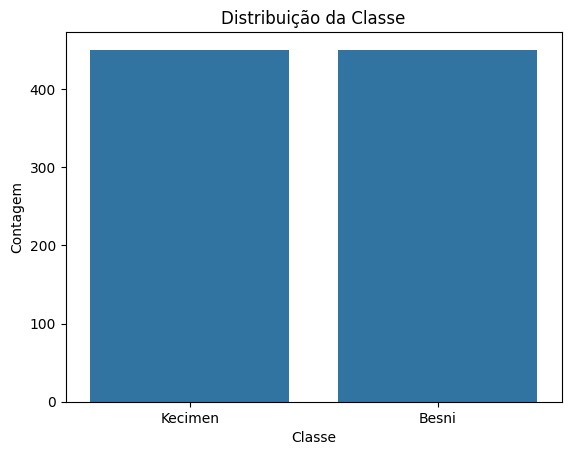

In [ ]:
# Analisando os dados do meu database

print(df.isnull().sum())
print("\nClasses no rótulo:")
print(df['Class'].unique())

   # Gráfico de barras para a variável alvo
sns.countplot(x='Class', data=df)
plt.title('Distribuição da Classe')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.show()

In [ ]:
# Separação dos dados entre dados de teste e treinamento.
# Features = características de uma certa classe
# Labels = classes em si

features = df.iloc[:,:-1].values
labels = df.iloc[:,-1].values
display(features[1, 1])
# Separando os dados

train_features, test_features, train_labels, test_labels = train_test_split(features, labels, test_size=0.2, random_state=42)

406.690687

In [ ]:
label = LabelEncoder()
train_labels = label.fit_transform(train_labels)
test_labels = label.transform(test_labels)

scaller = StandardScaler()
train_features = scaller.fit_transform(train_features)
test_features = scaller.transform(test_features)
U = train_features
U_test = test_features
Y = train_labels
Y_test = test_labels

In [ ]:
# Criaação e configurando a redes
model = tfk.models.Sequential()
# Camada de entrada
model.add(tfk.layers.Input(shape=(U.shape[1],)))

# Camada escondida
model.add(tfk.layers.Dense(30,activation='relu'))

# Camada de saída
model.add(tfk.layers.Dense(1,activation='sigmoid'))

# Configurando
opt = tfk.optimizers.Adam(learning_rate=1e-3) # otimizador
model.compile(optimizer=opt,
              loss='binary_crossentropy', # Função objetivo
              metrics=['accuracy','precision'])       # Métrica de avaliação

# Exibindo o modelo
model.summary()
print(U)
print(Y)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                     │ (None, 30)                  │             240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 1)                   │              31 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 271 (1.06 KB)

 Trainable params: 271 (1.06 KB)

 Non-trainable params: 0 (0.00 B)

[[-0.19754789  0.14897276 -0.44638417 ... -0.1745895  -0.45516513
   0.02724995]
 [-0.40008943 -0.84195474  0.54999871 ... -0.40711493  0.12644893
  -0.4268248 ]
 [-0.06253717 -0.44611797  0.66031667 ... -0.11124679  1.14554238
  -0.27168095]
 ...
 [ 1.9978914   1.51465121  1.87529558 ...  1.89284623  0.98834335
   1.4824537 ]
 [-1.52730925 -1.60874052 -2.07050112 ... -1.49774837 -1.40090526
  -1.77704118]
 [-0.77377526 -1.05253197 -0.26748965 ... -0.79789938  0.20231375
  -0.93999151]]
[1 1 1 0 1 0 1 1 1 1 1 1 0 0 1 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 1 0 1 0 0 1 0
 1 1 0 1 1 1 1 1 0 0 0 1 1 1 0 1 1 1 0 0 1 1 0 0 0 1 1 1 1 0 1 0 1 0 0 0 1
 0 1 1 1 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 0 1 1 0 0 1 1 1 0
 1 1 0 0 0 1 1 1 0 1 1 0 1 0 1 1 1 0 0 1 0 1 1 1 0 1 1 1 0 1 0 1 0 1 1 1 1
 0 0 1 0 0 0 1 1 0 1 1 1 1 1 1 0 1 1 1 0 1 0 0 0 0 0 0 1 0 1 1 1 1 0 0 1 1
 0 0 1 1 0 1 0 1 1 0 0 0 0 0 1 1 0 1 1 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 1 1 1
 0 1 1 0 1 0 0 0 1 1 0 0 1 1 0 1 1 1 1 1 0 0 0 0 1 0 0 1 1

In [ ]:
# Treinamento do modelo

unique_labels, label_counts = np.unique(train_labels, return_counts=True)
print("Classes únicas:", unique_labels)
print("Contagem de cada classe:", label_counts)
# Dado que o banco de dados já é naturalmente bem equilibrado entre as duas classes, é natural que as divisões também sejam.

opt = tfk.optimizers.Adam(learning_rate=1e-3) # otimizador
class_pesos = {0: label_counts[0] / (label_counts[0] + label_counts[1]),
               1: label_counts[1] / (label_counts[0] + label_counts[1])}

history = model.fit(U, Y, epochs=500, class_weight = class_pesos)

Classes únicas: [0 1]
Contagem de cada classe: [364 356]
Epoch 1/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7178 - loss: 0.3016 - precision: 0.6536
Epoch 2/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8083 - loss: 0.2499 - precision: 0.7583 
Epoch 3/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8441 - loss: 0.2238 - precision: 0.7920 
Epoch 4/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8365 - loss: 0.2063 - precision: 0.7877 
Epoch 5/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8566 - loss: 0.1969 - precision: 0.8207 
Epoch 6/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8359 - loss: 0.2047 - precision: 0.7839  
Epoch 7/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8511 - loss: 0.1878 - precision: 0.8020  
Epoch 8/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8775 - loss: 0.1693 - precision: 0.8544
Epoch 9/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8604 - loss: 0.1926 - precisio

Text(0.5, 0, 'Época')

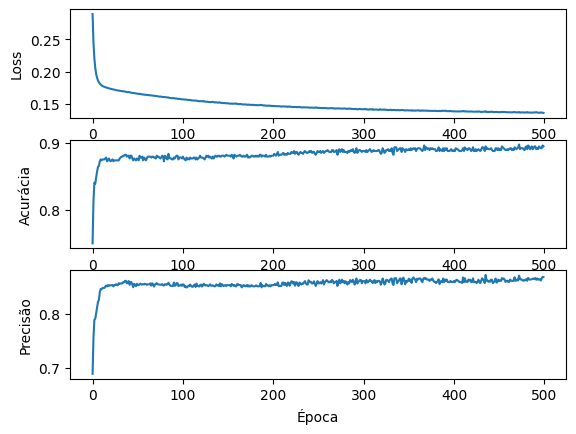

In [ ]:
# Verificando métricas atreladas ao treinamento

# Graficos
plt.subplot(3,1,1)
plt.plot(history.history['loss'])
plt.ylabel('Loss')
plt.subplot(3,1,2)
plt.plot(history.history['accuracy'])
plt.ylabel('Acurácia')
plt.subplot(3,1,3)
plt.plot(history.history['precision'])
plt.ylabel('Precisão')
plt.xlabel('Época')

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


<Figure size 640x480 with 0 Axes>

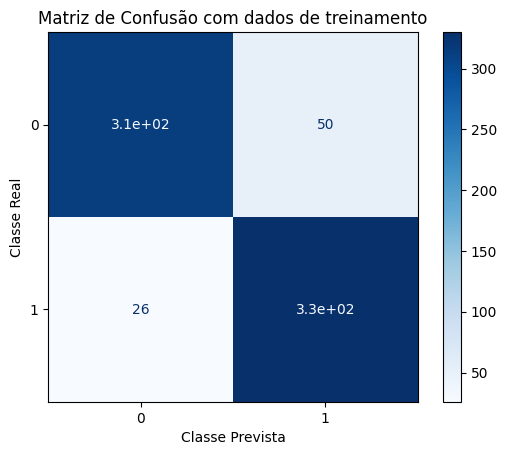

Acurácia: 0.8944444444444445
Precisão: 0.868421052631579
Recall: 0.9269662921348315
F1 Score: 0.8967391304347827
Especificidade: 0.8626373626373627


In [ ]:
# Matriz de confusão com dados de treinamentos

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
Y_pred = model.predict(U)
Y_pred[Y_pred>=0.5] = 1
Y_pred[Y_pred<0.5] = 0
cm = confusion_matrix(Y.flatten(),Y_pred.flatten()).astype(float)

plt.figure()
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão com dados de treinamento")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.grid(False)
plt.show()

TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

#Calculando métricas importantes para a discussão dos resultados
acuracia = (TP + TN) / (TP + TN + FP + FN)
precisao = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precisao * recall) / (precisao + recall)
especificidade = TN / (TN + FP)


print("Acurácia:", acuracia)
print("Precisão:", precisao)
print("Recall:", recall)
print("F1 Score:", f1_score)
print("Especificidade:", especificidade)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


<Figure size 640x480 with 0 Axes>

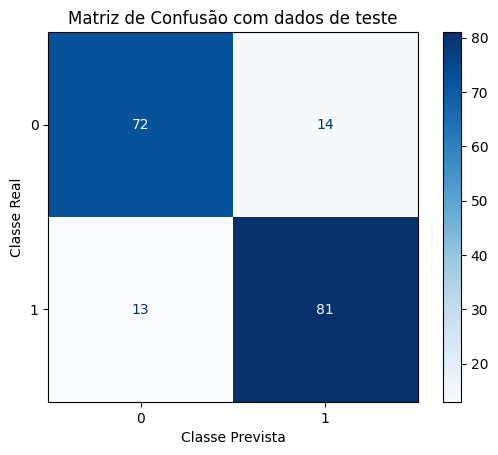

Acurácia: 0.85
Precisão: 0.8526315789473684
Recall: 0.8617021276595744
F1 Score: 0.8571428571428572
Especificidade: 0.8372093023255814


In [ ]:
# Matriz de confusão com dados de teste/validação

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
Y_pred = model.predict(U_test)
Y_pred[Y_pred>=0.5] = 1
Y_pred[Y_pred<0.5] = 0
cm = confusion_matrix(Y_test.flatten(),Y_pred.flatten()).astype(float)

plt.figure()
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão com dados de teste")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.grid(False)
plt.show()
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

#Calculando métricas importantes para a discussão dos resultados
acuracia = (TP + TN) / (TP + TN + FP + FN)
precisao = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precisao * recall) / (precisao + recall)
especificidade = TN / (TN + FP)


print("Acurácia:", acuracia)
print("Precisão:", precisao)
print("Recall:", recall)
print("F1 Score:", f1_score)
print("Especificidade:", especificidade)

##Discussão dos resultados


Os dados do dataset Raisin Binary Classification já encontravam-se bem equalizados de início. Para processamento dos dados, levou-se em consideração que as classes (Kecimen e Besni) seriam representadas por 0 e 1.Em razão da semelhante proporção das classes no dataset, não era esperado que uma classe tivesse desempenho consideravelmente superior à outra. Apesar disso, dado que, ao separar aleatoriamente os dados de treinamento e teste, foi encontrada uma pequena diferença nos resultados entre as daus classes.
Analisando a matriz de confusão dos dados de teste nas diagonais superior esquerda e inferior direita, que correspondem respectivamente aos valores de verdadeiros positivos e verdadeiros negativos, é possível verificar que a rede neural obteve bons resultados na identificação das classes. Resultados de falso positivo e falso negativo foram minorías.

No tocante às métricas, estas foram aquelas apresentadas pela rede neural considerando os dados de teste: acurácia de 0.85; Precisão de 0.853; Recall de 0.862; F1 Score de 0.857; Especificidade de 0.837.

É possível verificar que os resultados com os dados de treinamento se mostraram superiores àqueles encontrados com os dados de teste.